In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.compose import ColumnTransformer,make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler,FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor,HistGradientBoostingRegressor
import xgboost as xg
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


In [2]:
df=pd.DataFrame(pd.read_csv(r"C:\Users\Tharun R Gowda\Desktop\Github project\train.csv"))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [10]:
df.shape

(1460, 78)

In [41]:
# 1. Define your target
y = df['SalePrice']

# 2. Define your features (Everything EXCEPT the target and the ID)
X = df.drop(columns=['SalePrice']) 

# 3. Optional: Log Transform the target
# Many Ames Housing models perform better if you predict the log of SalePrice
import numpy as np
y_log = np.log1p(y)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

In [25]:
df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,3SsnPorch,ScreenPorch,PoolQC,Fence,MiscFeature,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,GdPrv,Shed,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,4,2010,WD,Normal,142125


In [29]:
(df['Alley']=='NaN').sum()
df['Alley'].isnull().sum()

np.int64(1369)

In [22]:
df.isnull().sum()

MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
Street             0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 78, dtype: int64

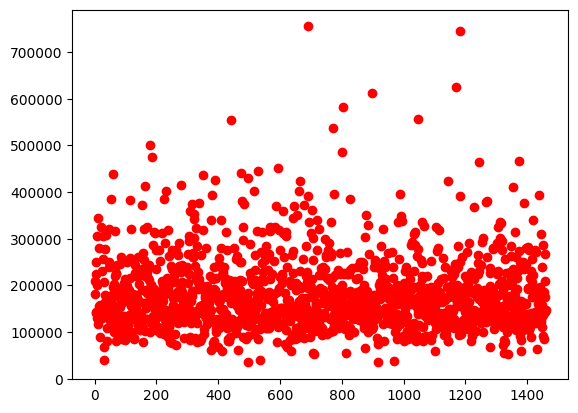

In [14]:
plt.scatter(df['Id'],df['SalePrice'],c='red')

In [30]:
num_df=df.select_dtypes(include=['number'])
print(num_df.corr())

               MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  \
MSSubClass       1.000000    -0.386347 -0.139781     0.032628    -0.059316   
LotFrontage     -0.386347     1.000000  0.426095     0.251646    -0.059213   
LotArea         -0.139781     0.426095  1.000000     0.105806    -0.005636   
OverallQual      0.032628     0.251646  0.105806     1.000000    -0.091932   
OverallCond     -0.059316    -0.059213 -0.005636    -0.091932     1.000000   
YearBuilt        0.027850     0.123349  0.014228     0.572323    -0.375983   
YearRemodAdd     0.040581     0.088866  0.013788     0.550684     0.073741   
MasVnrArea       0.022936     0.193458  0.104160     0.411876    -0.128101   
BsmtFinSF1      -0.069836     0.233633  0.214103     0.239666    -0.046231   
BsmtFinSF2      -0.065649     0.049900  0.111170    -0.059119     0.040229   
BsmtUnfSF       -0.140759     0.132644 -0.002618     0.308159    -0.136841   
TotalBsmtSF     -0.238518     0.392075  0.260833     0.537808   

In [3]:
df.drop(columns=['Id'],axis=1,inplace=True)

In [4]:
category_df_columns=(df.select_dtypes(include=['object'])).columns
for column in category_df_columns:
    print(column,':',df[column].unique())


MSZoning : ['RL' 'RM' 'C (all)' 'FV' 'RH']
Street : ['Pave' 'Grvl']
Alley : [nan 'Grvl' 'Pave']
LotShape : ['Reg' 'IR1' 'IR2' 'IR3']
LandContour : ['Lvl' 'Bnk' 'Low' 'HLS']
Utilities : ['AllPub' 'NoSeWa']
LotConfig : ['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']
LandSlope : ['Gtl' 'Mod' 'Sev']
Neighborhood : ['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel' 'Somerst' 'NWAmes'
 'OldTown' 'BrkSide' 'Sawyer' 'NridgHt' 'NAmes' 'SawyerW' 'IDOTRR'
 'MeadowV' 'Edwards' 'Timber' 'Gilbert' 'StoneBr' 'ClearCr' 'NPkVill'
 'Blmngtn' 'BrDale' 'SWISU' 'Blueste']
Condition1 : ['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe' 'RRNn' 'RRAn' 'PosA' 'RRNe']
Condition2 : ['Norm' 'Artery' 'RRNn' 'Feedr' 'PosN' 'PosA' 'RRAn' 'RRAe']
BldgType : ['1Fam' '2fmCon' 'Duplex' 'TwnhsE' 'Twnhs']
HouseStyle : ['2Story' '1Story' '1.5Fin' '1.5Unf' 'SFoyer' 'SLvl' '2.5Unf' '2.5Fin']
RoofStyle : ['Gable' 'Hip' 'Gambrel' 'Mansard' 'Flat' 'Shed']
RoofMatl : ['CompShg' 'WdShngl' 'Metal' 'WdShake' 'Membran' 'Tar&Grv' 'Roll'
 'ClyTile']
Ex

In [11]:
df.shape

(1460, 78)

In [7]:

garage = ['GarageType', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'GarageAge']
wood = ['WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch']
floor = ['1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea']
sale = ['MoSold', 'SaleType', 'SaleCondition']
outdoor = ['RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'PavedDrive', 'Fence']
interior = ['Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu']
area = ['MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'LandSlope', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2']
house = ['MSSubClass', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'Foundation', 'Utilities', 'HouseAge', 'RemodelAge']
basement = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']
pool = ['PoolQC', 'PoolArea']
special = ['MiscFeature', 'MiscVal']

all_grouped_cols = garage + wood + floor + sale + outdoor + interior + area + house + basement + pool+special
remaining=[col for col in df.columns if col not in all_grouped_cols]
print(remaining)

['SalePrice']


In [6]:
df['GarageAge']=df['YrSold']-df['GarageYrBlt']
df['HouseAge']=df['YrSold']-df['YearBuilt']
df['RemodelAge']=df['YrSold']-df['YearRemodAdd']
df.drop(columns=['YrSold','GarageYrBlt','YearBuilt','YearRemodAdd'],inplace=True)

In [8]:
nan_col=[col for col in all_grouped_cols if df[col].isnull().any()]
print(nan_col)

['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'GarageAge', 'MasVnrType', 'MasVnrArea', 'Fence', 'Electrical', 'FireplaceQu', 'LotFrontage', 'Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'PoolQC', 'MiscFeature']


In [9]:
num_col=[col for col in all_grouped_cols if df[col].dtype in ['int64','float64']]
print(num_col)
except_num=[col for col in num_col if col not in ['LotFrontage','MoSold','MSSubClass']]
print(except_num)


['GarageCars', 'GarageArea', 'GarageAge', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'MoSold', 'MasVnrArea', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'LotFrontage', 'LotArea', 'MSSubClass', 'OverallQual', 'OverallCond', 'HouseAge', 'RemodelAge', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'PoolArea', 'MiscVal']
['GarageCars', 'GarageArea', 'GarageAge', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'MasVnrArea', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'LotArea', 'OverallQual', 'OverallCond', 'HouseAge', 'RemodelAge', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'PoolArea', 'MiscVal']


In [10]:
nan_num=[col for col in num_col if df[col].isnull().sum()]
print(nan_num)

['GarageAge', 'MasVnrArea', 'LotFrontage']


In [11]:
cat_col=[col for col in all_grouped_cols if df[col].dtype in ['object']]
spl_col=['MSSubClass','MoSold']
for i in spl_col:
    cat_col.append(i)
print(cat_col)

['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'SaleType', 'SaleCondition', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'PavedDrive', 'Fence', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'LandSlope', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'Foundation', 'Utilities', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'PoolQC', 'MiscFeature', 'MSSubClass', 'MoSold']


In [29]:
standard_ordinals = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
exposure_ordinal = ['BsmtExposure']
bsmt_fin_ordinals = ['BsmtFinType1', 'BsmtFinType2']
garage_finish_ordinal = ['GarageFinish']
functional_ordinal = ['Functional'] 

# 6. Lot Shape Scale: (Reg > IR1 > IR2 > IR3)
lot_shape_ordinal = ['LotShape'] # [cite: 5]

# 7. Land Slope Scale: (Gtl > Mod > Sev)
land_slope_ordinal = ['LandSlope'] # [cite: 7]

# 8. Paved Drive Scale: (Y > P > N)
paved_drive_ordinal = ['PavedDrive'] # [cite: 30]

# 9. Fence Scale: (GdPrv > MnPrv > GdWo > MnWw > NA)
fence_ordinal = ['Fence'] # [cite: 31, 32]

# 10. Utilities Scale: (AllPub > NoSewr > NoSeWa > ELO)
utilities_ordinal = ['Utilities'] # [cite: 6]
ordinal_mappings = {
    'standard': (standard_ordinals, ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex']),
    'exposure': (exposure_ordinal, ['NA', 'No', 'Mn', 'Av', 'Gd']),
    'fin_type': (bsmt_fin_ordinals, ['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']),
    'garage_fin': (garage_finish_ordinal, ['NA', 'Unf', 'RFn', 'Fin']),
    'functional': (functional_ordinal, ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ']),
    'lot_shape': (lot_shape_ordinal, ['IR3', 'IR2', 'IR1', 'Reg']),
    'land_slope': (land_slope_ordinal, ['Sev', 'Mod', 'Gtl']),
    'paved_drive': (paved_drive_ordinal, ['N', 'P', 'Y']),
    'fence': (fence_ordinal, ['NA', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv']),
    'utilities': (utilities_ordinal, ['ELO', 'NoSeWa', 'NoSewr', 'AllPub'])
}
# Apply the mapping to the dataframe
for group_name, (cols, categories) in ordinal_mappings.items():
    # 1. Create the dictionary as before
    mapping_dict = {category: i for i, category in enumerate(categories)}
    
    # 2. THE FIX: Explicitly tell it that a Null (NaN) is also 0
    import numpy as np
    mapping_dict[np.nan] = 0 
    
    for col in cols:
        df[col] = df[col].map(mapping_dict)

In [30]:
ohe_cols=[col for col in df.columns if df[col].dtype == 'object' or col in ['MSSubClass', 'MoSold']]
med_col=['LotFrontage']

In [34]:
def my_mapping_logic(X):
    X_copy = X.copy()
    # Use your existing ordinal_mappings dictionary
    for group_name, (cols, categories) in ordinal_mappings.items():
        mapping_dict = {cat: i for i, cat in enumerate(categories)}
        mapping_dict[np.nan] = 0
        for col in cols:
            if col in X_copy.columns:
                X_copy[col] = X_copy[col].map(mapping_dict).fillna(0)
    return X_copy

# 2. Wrap it so ColumnTransformer understands it
map_transformer = FunctionTransformer(my_mapping_logic)

In [ ]:
all_ordinal_cols = [col for group in ordinal_mappings.values() for col in group[0]]
ord_pipe = Pipeline([
    ('mapper', FunctionTransformer(my_mapping_logic)),
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

transformer = ColumnTransformer(
    transformers=[
        ('ord', ord_pipe, all_ordinal_cols), # Run your custom mapping logic here
        ('med', Pipeline([('imp', SimpleImputer(strategy='median')), ('scalar', StandardScaler())]), med_col),
        ('num', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value=0)), ('scalar', StandardScaler())]), except_num),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ohe_cols)
    ]
)
# tuned_hgb = HistGradientBoostingRegressor(
#     max_iter=1000,           # Similar to n_estimators (more trees)
#     learning_rate=0.01,      # Slow down learning for better precision
#     max_depth=5,             # Keep it shallow to prevent overfitting
#     l2_regularization=1.0,   # Add a penalty to prevent the model from getting too "wild"
#     max_bins=255,            # Default is 255, usually fine
#     random_state=42
# )
xgb_reg = xg.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,   # Slow learning is key
    max_depth=4,          # Shallow trees prevent overfitting
    subsample=0.8,        # Stochastic gradient boosting
    colsample_bytree=0.8, # Feature subsampling
    reg_alpha=0.1,        # L1 regularization
    reg_lambda=1.0,       # L2 regularization
    random_state=42
)
lgbm_reg = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    num_leaves=31,         # Main complexity control
    max_depth=-1,          # Let leaf-wise growth handle depth
    feature_fraction=0.8,  # Subsampling features
    bagging_fraction=0.8,   # Subsampling data
    bagging_freq=5,
    random_state=42,
    verbose=-1             # Keeps the output clean
)

final_pipe = Pipeline([
    ('preprocessor', transformer),
    ('pca', PCA(n_components=0.95)),
    ('regressor',lgbm_reg)
])
# param_grid_rf = {
#     'pca__n_components': [0.90, 0.95],
#     'regressor__n_estimators': [100, 200, 300,400 ],
#     'regressor__max_depth': [None, 2,4,6,8,5],
#     'regressor__min_samples_split': [2, 5, 10,15],
#     'regressor__max_features': ['sqrt', 'log2']
# }

# grid_rf = GridSearchCV(final_pipe, param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
# # Note: n_jobs=-1 uses all your computer's processors to speed it up!
final_pipe.fit(X, y_log)

# print("Best RF Score:", final_pipe.best_score_)
# print("Best Parameters:", final_pipe.best_params_)
scores = cross_val_score(final_pipe, X, y, cv=5, scoring='r2')

print(f"Average R2 Score: {scores.mean():.4f}")

c:\Users\Tharun R Gowda\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Tharun R Gowda\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Tharun R Gowda\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Tharun R Gowda\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Average R2 Score: 0.8655


c:\Users\Tharun R Gowda\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [66]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

# 1. Define your base models (The "Workers")
# We use the best versions of each that you've found
base_models = [
    ('xgb', xg.XGBRegressor(n_estimators=1000, learning_rate=0.01, max_depth=4, random_state=42)),
    ('lgbm', LGBMRegressor(n_estimators=1000, learning_rate=0.01, verbose=-1, random_state=42)),
    ('lasso', Lasso(alpha=0.0005))
]

# 2. Define the Stacking Regressor
# The final_estimator (Meta-Learner) is usually a simple RidgeCV
stack_reg = StackingRegressor(
    estimators=base_models,
    final_estimator=RidgeCV(), 
    cv=5
)

# 3. Put it in the Pipeline
# TRY THIS: Set n_components=None to see if the score jumps!
stack_pipe = Pipeline([
    ('preprocessor', transformer),
    ('pca', PCA(n_components=0.95)), 
    ('regressor', stack_reg)
])

# 4. Final Cross-Validation
stack_scores = cross_val_score(stack_pipe, X, np.log1p(y), cv=5, scoring='r2')
print(f"Stacking Ensemble R2 Score: {stack_scores.mean():.4f}")

c:\Users\Tharun R Gowda\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Tharun R Gowda\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Tharun R Gowda\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Tharun R Gowda\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Tharun R Gowda\AppData\Local\Programs\Python\Python310\lib\site-pac

Stacking Ensemble R2 Score: 0.8872


c:\Users\Tharun R Gowda\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Tharun R Gowda\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [69]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

from catboost import CatBoostRegressor

base_models_plus_cat = [
    ('xgb', xg.XGBRegressor(n_estimators=1000, learning_rate=0.01, max_depth=4, random_state=42)),
    ('lgbm', LGBMRegressor(n_estimators=1000, learning_rate=0.01, verbose=-1, random_state=42)),
    ('cat', CatBoostRegressor(iterations=1000, learning_rate=0.01, depth=6, verbose=0, random_state=42)),
    ('lasso', Lasso(alpha=0.0005))
]

# 1. Define the Stacking Object with all 4 "Titans"
stack_reg_final = StackingRegressor(
    estimators=base_models_plus_cat, # Use the list you just made
    final_estimator=RidgeCV(),       # The meta-learner
    cv=5
)

# 2. Re-build the Pipeline WITHOUT PCA
# By setting 'pca' to 'passthrough' or None, the trees get the raw engineered features
stack_pipe_final = Pipeline([
    ('preprocessor', transformer),
    ('pca', 'passthrough'), 
    ('regressor', stack_reg_final)
])

# 3. Run the Cross-Validation
# This might take 1-2 minutes because CatBoost is thorough
stack_scores = cross_val_score(stack_pipe_final, X, np.log1p(y), cv=5, scoring='r2')

print(f"Final Stacking Ensemble R2 Score: {stack_scores.mean():.4f}")

Final Stacking Ensemble R2 Score: 0.9015
